# DINOv2 自监督特征提取训练

## 概述
- **基础模型**: `dinov2-base`（HuggingFace Transformers）
- **训练方式**: DINO 自蒸馏（student-teacher），EMA 动量更新 teacher
- **数据增强**: Multi-crop：2 个 global crops (224×224) + 6 个 local crops (96×96)
- **损失函数**: Cross-entropy between softened teacher & student distributions，含 center-momentum 去偏
- **投影维度**: 256
- **输出**: 全局特征向量（CLS token 经投影头）
- **模型保存**: 每 epoch 保存 `dino_epoch_{N}.pth`（含 student/teacher state_dict + optimizer + center）

In [ ]:
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
import os, math, time, json, copy
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from einops import rearrange
import copy
from tqdm import tqdm
from matplotlib import pyplot as plt
os.environ['KMP_DUPLICATE_LIB_OK']='True'
os.environ['HF_HOME'] = '../checkpoints'

IMAGE_ROOT = r'../image-matching-challenge-2025/train'
CHECKPOINT_DIR = r'../checkpoints/dinov2'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

input_size = 224
local_crop_size = 96
num_local_crops = 6
BATCH_SIZE = 64
EPOCHS = 100
BASE_LR = 1e-4
WEIGHT_DECAY = 1e-4
PROJECT_DIM = 256
STUDENT_TEMP = 0.1
TEACHER_TEMP = 0.04
EMA_M = 0.996
BACKBONE = '../models/dinov2-base'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
device

device(type='cuda')

## 2. 多尺度裁剪数据增强

Multi-Crop Augmentation: 每个样本生成 2 个 global crops + N 个 local crops。
- Global crops: 大尺度随机裁剪 (scale 0.14~1.0)，配合 ColorJitter + Grayscale + GaussianBlur
- Local crops: 小尺度随机裁剪 (scale 0.05~0.14)，仅 ColorJitter + Grayscale
- Teacher 只看 global crops，Student 看所有 crops

In [23]:
class MultiCropAugment:
    def __init__(self, global_size=224, local_size=96, n_local=6):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(global_size, scale=(0.14, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=23, sigma=(0.1,2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(local_size, scale=(0.05, 0.14)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ])
        self.n_local = n_local

    def __call__(self, img):
        crops = []
        crops.append(self.global_transform(img))
        crops.append(self.global_transform(img))
        for _ in range(self.n_local):
            crops.append(self.local_transform(img))
        return crops

In [24]:
class ImageFolderDataset(Dataset):
    def __init__(self, root, transform):
        self.root = Path(root)
        self.transform = transform
        image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        self.paths = sorted(
            p for p in self.root.rglob('*')
            if p.is_file() and p.suffix.lower() in image_exts and p.name.lower() != 'license.txt'
        )
        if len(self.paths) == 0:
            raise ValueError(f'No image files found under: {self.root.resolve()}')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert('RGB')
        crops = self.transform(img)
        return crops, str(p)

In [25]:
transform = MultiCropAugment(global_size=input_size, local_size=local_crop_size, n_local=num_local_crops)
dataset = ImageFolderDataset(IMAGE_ROOT, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=False)
print(f'Loaded {len(dataset)} training images from {Path(IMAGE_ROOT).resolve()}')

Loaded 1945 training images from C:\Users\xieyi\Desktop\test\kaggle\Image-Matching-and-3D-Reconstruction\image-matching-challenge-2025\train


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07450981116294864..1.0000000236034394].


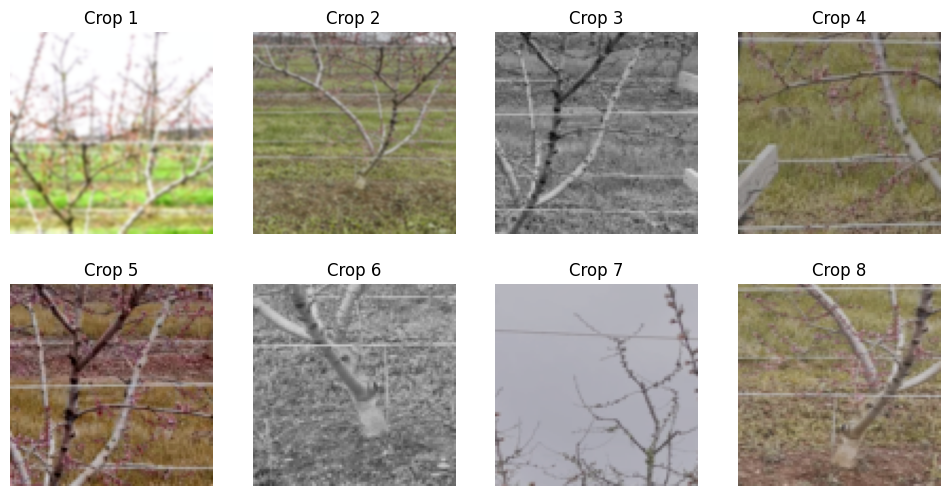

In [26]:
example_crops, example_path = dataset[0]
plt.figure(figsize=(12,6))
for i, crop in enumerate(example_crops):
    plt.subplot(2, 4, i+1)
    plt.imshow(crop.permute(1,2,0).numpy() * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
    plt.title(f'Crop {i+1}')
    plt.axis('off')

## 4. DINO 模型架构

- **DINOBackbone**: DINOv2-base ViT encoder + 可学习投影头（hidden_size → 256）
- **DINOHead**: 3 层 MLP（256 → 2048 → 256），GELU 激活
- **DINO**: Backbone + Head 组合
- Student 和 Teacher 同构，Teacher 通过 EMA 更新（不参与梯度计算）

In [ ]:
class DINOBackbone(nn.Module):
    def __init__(self, model_name=BACKBONE):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name, local_files_only=True)
        self.projector = nn.Linear(self.model.config.hidden_size, PROJECT_DIM)

    def forward(self, x):
        features = self.model(x).last_hidden_state[:,0]
        projected = self.projector(features)
        return projected
    
class DINOHead(nn.Module):
    def __init__(self, in_dim=PROJECT_DIM, out_dim=PROJECT_DIM, hidden_dim=2048):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.mlp(x)
    
class DINO(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, x):
        features = self.backbone(x)
        output = self.head(features)
        return output

In [28]:
backbone = DINOBackbone().to(device)
head = DINOHead().to(device)
student = DINO(backbone, head).to(device)
teacher = copy.deepcopy(student).to(device)
for p in teacher.parameters():
    p.requires_grad = False

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': './models/dinov2-base'. Use `repo_type` argument if needed.

## 5. EMA 更新 & 优化器 & Center

- **EMA (Exponential Moving Average)**: teacher = m * teacher + (1-m) * student，m=0.996
- **Center**: 对 teacher 输出做指数移动平均去偏，防止模型坍塌
- 使用 AdamW + AMP 混合精度训练

In [9]:
def update_teacher(student, teacher, ema_m):
    for s_p, t_p in zip(student.parameters(), teacher.parameters()):
        t_p.data = ema_m * t_p.data + (1 - ema_m) * s_p.data
        
class Center:
    def __init__(self, dim, momentum=0.9):
        self.m = momentum
        self.center = torch.zeros(dim).to(device)

    @torch.no_grad()
    def update(self, teacher_outputs):
        batch_center = teacher_outputs.mean(dim=0)
        self.center = self.m * self.center + (1 - self.m) * batch_center
       
center = Center(PROJECT_DIM, momentum=0.9)
optimizer = torch.optim.AdamW(student.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler()

In [10]:
def dino_loss_fn(student_outputs, teacher_outputs, temp_student=STUDENT_TEMP, temp_teacher=TEACHER_TEMP):
    loss = 0.0
    n_loss_terms = 0
    t_out = [((out-center.center.unsqueeze(0))/temp_teacher).softmax(dim=-1) for out in teacher_outputs]
    s_out = [((out/temp_student)) for out in student_outputs]
    for t in t_out:
        for s in s_out:
            log_s = torch.log_softmax(s, dim=-1)
            loss_term = -(t * log_s).sum(dim=-1).mean()
            loss += loss_term
            n_loss_terms += 1
    loss = loss / n_loss_terms
    return loss

In [ ]:
global_step = 0
history = {'train_loss': [], 'lr': []}

for epoch in range(EPOCHS):
    student.train()
    epoch_loss = 0.0
    t0 = time.time()
    for batch in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        crops_batch, paths = batch
        views = [crop.to(device, non_blocking=True) for crop in crops_batch]
        student_outputs = []
        teacher_outputs = []
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            for v in views:
                student_outputs.append(student(v))
            with torch.no_grad():
                for v in views:
                    teacher_outputs.append(teacher(v))
        loss = dino_loss_fn(student_outputs, teacher_outputs, STUDENT_TEMP, TEACHER_TEMP)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_teacher(student, teacher, EMA_M)
        with torch.no_grad():
            concat_teacher = torch.cat(teacher_outputs, dim=0)
            batch_center = concat_teacher.mean(dim=0)
            center.update(batch_center)
        epoch_loss += loss.item()
        global_step += 1

    avg_loss = epoch_loss / len(loader)
    history['train_loss'].append(avg_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    t1 = time.time()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Time: {t1-t0:.1f}s")

    ckpt = {
        'student_state': student.state_dict(),
        'teacher_state': teacher.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'center': center.center.cpu().numpy(),
    }
    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f'dino_epoch_{epoch+1}.pth'))

print(f'\nTraining complete.')

# ── 保存损失历史到 CSV ──
import pandas as pd
df_loss = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'lr': history['lr'],
})
csv_path = os.path.join(CHECKPOINT_DIR, 'training_loss.csv')
df_loss.to_csv(csv_path, index=False)
print(f'Loss history saved to {csv_path}')

## 8. 全局特征推理函数

训练完成后，加载最优 checkpoint 进行全局特征提取：
- 仅使用 Student 的 Backbone（去掉 Head）
- 输入单张 RGB 图 → CLS token → 投影 → 256 维全局特征
- 用于后续 Phase 2 多模型图像检索

In [ ]:
def load_student_from_checkpoint(path, model):
    ck = torch.load(path, map_location=device)
    model.load_state_dict(ck['student_state'], strict=False)
    model.to(device)
    model.eval()
    return model

def extract_global_features(model, image_paths, transform_single, batch_size=32):
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            imgs = []
            for p in batch_paths:
                im = Image.open(p).convert('RGB')
                x = transform_single(im).unsqueeze(0)
                imgs.append(x)
            x = torch.cat(imgs, dim=0).to(device)
            out = model(x)
            feats.append(out.cpu())
    feats = torch.cat(feats, dim=0)
    return feats

transform_single = transforms.Compose([
    transforms.Resize(int(input_size*1.14)),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])